In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from dnd_dynamics.analysis import data_loading as dl
from dnd_dynamics.analysis import metrics
from dnd_dynamics.analysis import plot_utils as pu

plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams.update({'font.size': 8})

OUTPUT_DIR = Path('plots/seminar')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Anthropic API key loaded
OpenAI API key loaded
Gemini API key loaded


In [2]:
CAMPAIGN_BASE_NAMES = [
    '1262-firedeath-must-die-closed-play-by-post-open-ogg',
    '3135-the-head-of-the-serpent',
    '10391-guardians-of-gridori',
    '20049-age-of-death',
    '89221-banhaven-academy-year-1',
    '90630-firecat5s-dragon-of-icespire-peak',
    '7426-serpent-isle-private-campaign',
]

LLM_FILTER = {
    'model': ['gpt-4o', 'gemini-1.5-pro', 'claude-3-7-sonnet-latest'],
    'campaign_name': CAMPAIGN_BASE_NAMES,
    'include_player_personalities': [False],
    'year': 2025,
    'scratchpad': True,
}

CATEGORY_FIELDS = ['model', 'include_player_personalities']

CATEGORY_ORDER = [
    'human',
    'model:gemini-1.5-pro, include_player_personalities:False',
    'model:claude-3-7-sonnet-latest, include_player_personalities:False',
    'model:gpt-4o, include_player_personalities:False',
]

LABELS = ['Human', 'Gemini', 'Claude', 'ChatGPT']

MESSAGES_PER_SESSION = 10
EMBEDDING_MODEL = "all-mpnet-base-v2"#"all-MiniLM-L6-v2"  # or 

In [3]:
dfs_human = dl.load_campaigns(CAMPAIGN_BASE_NAMES, messages_per_session=MESSAGES_PER_SESSION)
dfs_llm = dl.load_campaigns('llm', messages_per_session=MESSAGES_PER_SESSION, filter_by=LLM_FILTER)
dfs = {**dfs_human, **dfs_llm}

print(f"Loaded {len(dfs_human)} human campaigns, {len(dfs_llm)} LLM campaigns")

Filter matched 21 campaigns
Loading 21 campaigns from /Users/annie/Code/Repositories/dnd-dynamics/data/llm-games/game-logs


Loading campaigns: 100%|██████████| 21/21 [00:01<00:00, 18.78it/s]

Loaded 21 campaigns (5,073 messages)
Loaded 7 human campaigns, 21 LLM campaigns


In [9]:
from dnd_dynamics import config
config.SENTENCE_EMBEDDING_MODEL = EMBEDDING_MODEL

all_metrics = metrics.analyze_all(dfs, metrics=['basic', 'semantic', 'dsi'], force_refresh=True)

basic_metrics = all_metrics['basic']
semantic_metrics = all_metrics['semantic']
dsi_metrics = all_metrics['dsi']

Analyzing campaigns: 100%|██████████| 28/28 [00:00<00:00, 317.37it/s]


💾 Saved 28 basic metrics results to cache


Analyzing semantic:   0%|          | 0/28 [00:00<?, ?it/s]

Loading embedding model all-mpnet-base-v2 on mps...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

Cached embeddings to: /Users/annie/Code/Repositories/dnd-dynamics/data/processed/embeddings_cache/embeddings_822cfbe1bdaceb9ef05159459c9ec7b0.pkl
💾 Saved 28 semantic results to cache


Analyzing campaign DSI:   0%|          | 0/28 [00:00<?, ?it/s]

Loading BERT model bert-base-uncased on mps (first time only)...
BERT model bert-base-uncased loaded and cached on mps


Analyzing campaign DSI: 100%|██████████| 28/28 [02:48<00:00,  6.01s/it]

💾 Saved 28 DSI results to cache


In [10]:
campaign_names = list(dfs.keys())
categories = pu.categorize_campaigns(campaign_names, CATEGORY_FIELDS)

post_len_agg, _ = pu.aggregate_metric(basic_metrics, campaign_names, categories, CATEGORY_ORDER, 'post_lengths')
session_cohesion_agg, _ = pu.aggregate_metric(semantic_metrics, campaign_names, categories, CATEGORY_ORDER, 'session_cohesion')
dsi_agg, _ = pu.aggregate_metric(dsi_metrics, campaign_names, categories, CATEGORY_ORDER, 'dsi_scores')

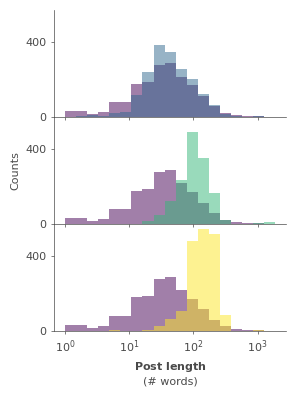

In [11]:
pu.plot_comparison_histograms(
    post_len_agg,
    bins=20,
    log_bins=True,
    labels=LABELS,
    xlabel=r'$\mathbf{Post\ length}$' + '\n(# words)',
    figsize=(3, 4))
plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.savefig(OUTPUT_DIR / 'post_length.pdf', transparent=True)

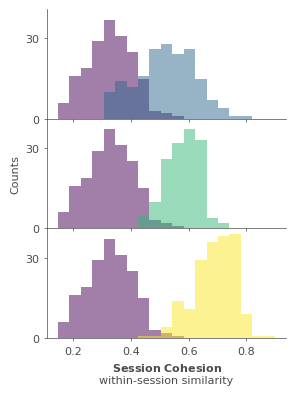

In [12]:
pu.plot_comparison_histograms(
    session_cohesion_agg,
    bins=20,
    labels=LABELS,
    xlabel=r'$\mathbf{Session\ Cohesion}$' + '\nwithin-session similarity',
    figsize=(3, 4))
plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.savefig(OUTPUT_DIR / 'session_cohesion.pdf', transparent=True)

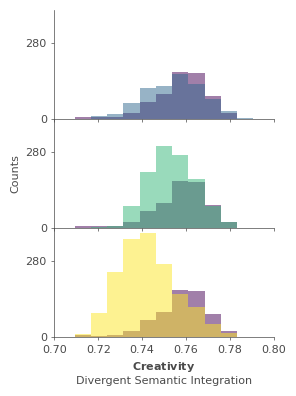

In [13]:
pu.plot_comparison_histograms(
    dsi_agg,
    bins=20,
    labels=LABELS,
    xlabel=r'$\mathbf{Creativity}$' + '\nDivergent Semantic Integration',
    figsize=(3, 4))
plt.xlim(.7, .8)
plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.savefig(OUTPUT_DIR / 'dsi.pdf', transparent=True)